# Notebook 13 — LSA bottleneck (TF-IDF → TruncatedSVD → classifier)

**Goal:** Reduce dimensionality with **TruncatedSVD** (100–200 components) after limited TF-IDF, then classify with **LinearSVC** or **LogisticRegression**.

**Outputs:** `models/lsa_pipeline.joblib`, `reports/nb13_metrics.json`


## 0. Imports and configuration

In [5]:
import sys
import json
import yaml
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay,
)

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'
CONFIG_BEST = PROJECT_ROOT / 'configs' / 'best_params.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)
with open(CONFIG_BEST) as f: best_cfg = yaml.safe_load(f)

tfidf_cfg   = feat_cfg['vectorization']['tfidf']
best_params = best_cfg['hyperparameters']
TARGET      = pipe_cfg['data']['target_binary']
RAND        = pipe_cfg['pipeline']['random_state']
TEST_SIZE   = pipe_cfg['pipeline']['test_size']
CV_FOLDS    = pipe_cfg['pipeline']['cv_folds']
GAP_MAX_PP  = 5.0
F1_TEST_MIN = 0.70

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'Target: {TARGET} | test_size={TEST_SIZE} | random_state={RAND}')


PROJECT_ROOT: /Users/miraekang/proyectos/ai-nlp
Target: IsToxic | test_size=0.2 | random_state=42


## 1. Load data and split

In [6]:
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'
if not PROCESSED.exists():
    raise FileNotFoundError(
        f'Missing {PROCESSED}. Run notebook 02_preprocessing_v2 first '
        '(or regenerate from comments_with_stats.csv as in nb09).'
    )

df = pd.read_csv(PROCESSED)
df['clean_text'] = df['clean_text'].fillna('').astype(str)
X, y = df['clean_text'], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND, stratify=y
)
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RAND)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Toxic rate train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')


Train: 800 | Test: 200
Toxic rate train: 46.2% | test: 46.0%


## 2. Helpers

In [7]:
def scores_for_roc(pipeline, X):
    """Probability or decision scores for ROC-AUC (LinearSVC has no predict_proba)."""
    final_est = pipeline[-1]
    if hasattr(final_est, 'predict_proba'):
        return pipeline.predict_proba(X)[:, 1]
    return pipeline.decision_function(X)


def evaluate_fitted(pipeline, name, run_cv=True):
    pred_tr = pipeline.predict(X_train)
    pred_te = pipeline.predict(X_test)
    score_te = scores_for_roc(pipeline, X_test)

    f1_tr = f1_score(y_train, pred_tr, average='weighted')
    f1_te = f1_score(y_test, pred_te, average='weighted')
    gap_pp = abs(f1_tr - f1_te) * 100
    roc = roc_auc_score(y_test, score_te)

    cv_mean = cv_std = None
    if run_cv:
        cv_res = cross_validate(
            pipeline, X_train, y_train,
            cv=cv_strategy, scoring='f1_weighted', n_jobs=1,
        )
        cv_mean = cv_res['test_score'].mean()
        cv_std  = cv_res['test_score'].std()

    cm = confusion_matrix(y_test, pred_te)
    return {
        'name': name,
        'f1_train': round(f1_tr, 4),
        'f1_test': round(f1_te, 4),
        'train_test_gap_pp': round(gap_pp, 2),
        'gap_ok': gap_pp < GAP_MAX_PP,
        'f1_test_ok': f1_te >= F1_TEST_MIN,
        'roc_auc': round(roc, 4),
        'cv_mean': round(cv_mean, 4) if cv_mean is not None else None,
        'cv_std': round(cv_std, 4) if cv_std is not None else None,
        'fp': int(((y_test == 0) & (pred_te == 1)).sum()),
        'fn': int(((y_test == 1) & (pred_te == 0)).sum()),
        'cm': cm.tolist(),
    }


def passes_agents(m):
    return m['gap_ok'] and m['f1_test_ok']


def make_lsa_pipeline(n_components, clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=500,
            min_df=5,
            ngram_range=(1, 1),
            sublinear_tf=False,
            analyzer='word',
            strip_accents='unicode',
        )),
        ('svd', TruncatedSVD(n_components=n_components, random_state=RAND)),
        ('clf', clf),
    ])


## 3. Compare LinearSVC vs LogisticRegression × SVD components

In [8]:
N_COMPONENTS_GRID = [100, 150, 200]
rows = []

for n_comp in N_COMPONENTS_GRID:
    for clf_name, clf in [
        ('LinearSVC', LinearSVC(class_weight='balanced', max_iter=3000, random_state=RAND)),
        ('LogisticRegression', LogisticRegression(
            C=0.1, max_iter=2000, class_weight='balanced', solver='lbfgs', random_state=RAND,
        )),
    ]:
        pipe = make_lsa_pipeline(n_comp, clf)
        pipe.fit(X_train, y_train)
        m = evaluate_fitted(pipe, name=f'{clf_name} n={n_comp}', run_cv=False)
        m['n_components'] = n_comp
        m['classifier'] = clf_name
        rows.append(m)

comp_df = pd.DataFrame(rows).sort_values(
    ['gap_ok', 'f1_test_ok', 'train_test_gap_pp', 'f1_test'],
    ascending=[False, False, True, False],
)
print(comp_df[['classifier', 'n_components', 'f1_test', 'f1_train', 'train_test_gap_pp', 'gap_ok']].to_string(index=False))

candidates = comp_df[comp_df['gap_ok'] & comp_df['f1_test_ok']]
winner = (candidates if not candidates.empty else comp_df).iloc[0]
WINNER_CLF = winner['classifier']
WINNER_N = int(winner['n_components'])
print(f"\nWinner: {WINNER_CLF}, n_components={WINNER_N}")


        classifier  n_components  f1_test  f1_train  train_test_gap_pp  gap_ok
LogisticRegression           100   0.7170    0.7579               4.09    True
LogisticRegression           150   0.7324    0.7819               4.94    True
LogisticRegression           200   0.7271    0.7845               5.74   False
         LinearSVC           100   0.7181    0.7859               6.77   False
         LinearSVC           150   0.7186    0.7983               7.97   False
         LinearSVC           200   0.6968    0.8274              13.06   False

Winner: LogisticRegression, n_components=100


## 4. Final pipeline

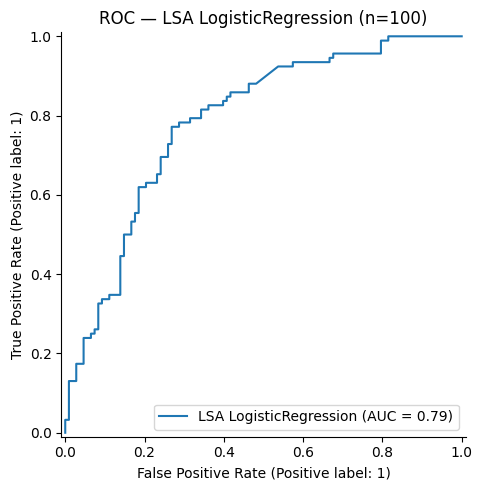

              precision    recall  f1-score   support

        Safe       0.71      0.81      0.76       108
       Toxic       0.73      0.62      0.67        92

    accuracy                           0.72       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.72      0.72       200



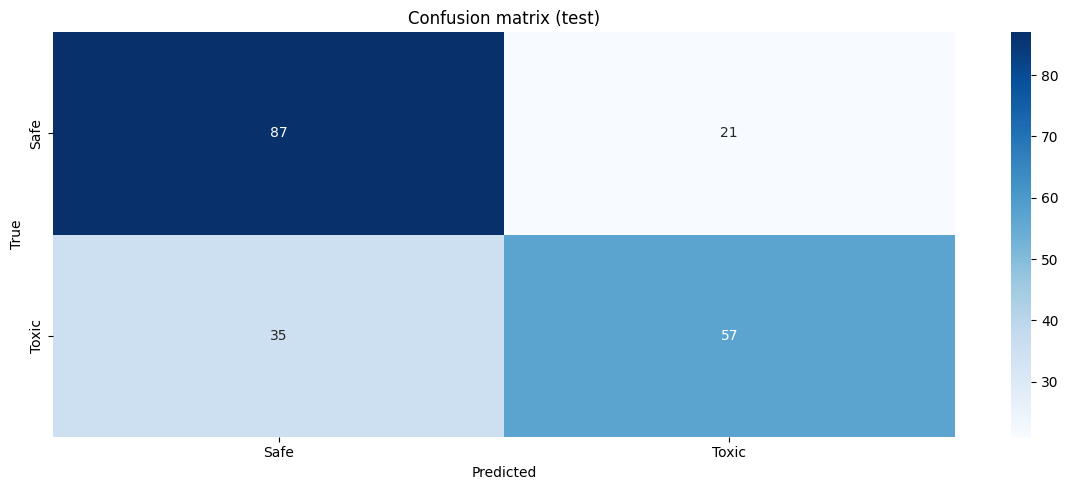

In [9]:
if WINNER_CLF == 'LinearSVC':
    final_clf = LinearSVC(class_weight='balanced', max_iter=3000, random_state=RAND)
else:
    final_clf = LogisticRegression(
        C=0.1, max_iter=2000, class_weight='balanced', solver='lbfgs', random_state=RAND,
    )

final_pipe = make_lsa_pipeline(WINNER_N, final_clf)
final_pipe.fit(X_train, y_train)
metrics_final = evaluate_fitted(final_pipe, f'LSA {WINNER_CLF} (nb13)')

if WINNER_CLF == 'LinearSVC':
    print('LinearSVC: ROC-AUC uses decision_function scores (no predict_proba).')

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, scores_for_roc(final_pipe, X_test), ax=ax, name=f'LSA {WINNER_CLF}',
)
ax.set_title(f'ROC — LSA {WINNER_CLF} (n={WINNER_N})')
plt.tight_layout()
plt.show()

print(classification_report(y_test, final_pipe.predict(X_test), target_names=['Safe', 'Toxic']))
cm = confusion_matrix(y_test, final_pipe.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
plt.title('Confusion matrix (test)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 5. Save

In [10]:
MODEL_PATH = PROJECT_ROOT / 'models' / 'lsa_pipeline.joblib'
METRICS_PATH = PROJECT_ROOT / 'reports' / 'nb13_metrics.json'
joblib.dump(final_pipe, MODEL_PATH)

payload = {
    'notebook': '13_lsa_bottleneck_v2',
    'n_components': WINNER_N,
    'classifier': WINNER_CLF,
    'metrics': metrics_final,
    'comparison': comp_df[['classifier', 'n_components', 'f1_test', 'train_test_gap_pp', 'gap_ok']].to_dict('records'),
}
with open(METRICS_PATH, 'w') as f:
    json.dump(payload, f, indent=2)

print(f'Saved → {MODEL_PATH}')


Saved → /Users/miraekang/proyectos/ai-nlp/models/lsa_pipeline.joblib


## 6. Conclusion

In [11]:
print(f"""
CONCLUSION — NOTEBOOK 13 (LSA BOTTLENECK)
==========================================
Winner: {WINNER_CLF} with TruncatedSVD n_components={WINNER_N}.

Test F1 (weighted): {metrics_final['f1_test']:.4f}
Train–test gap:     {metrics_final['train_test_gap_pp']:.2f} pp
AGENTS constraints: {'PASS' if passes_agents(metrics_final) else 'FAIL'}

Artifacts: models/lsa_pipeline.joblib, reports/nb13_metrics.json
""")



CONCLUSION — NOTEBOOK 13 (LSA BOTTLENECK)
Winner: LogisticRegression with TruncatedSVD n_components=100.

Test F1 (weighted): 0.7170
Train–test gap:     4.09 pp
AGENTS constraints: PASS

Artifacts: models/lsa_pipeline.joblib, reports/nb13_metrics.json

